# Poison test

In [2]:
import torch
import torch.utils.data as data
import torchvision.transforms as transforms
import torchvision.datasets as dset
import matplotlib.pyplot as plt

DATA_PATH = "./data"

# Assumed constants -- easy to tune later
WATERMARK_ALPHA = 0.2
PIXEL_BLOCK_SIZE = 4
PIXEL_BLOCK_INTENSITY = 1.0  # full white, on a [0, 1] pixel scale

WATERMARK_SOURCE_LABEL, WATERMARK_TARGET_LABEL = 1, 7
PIXEL_SOURCE_LABEL, PIXEL_TARGET_LABEL = 4, 5

In [3]:
def load_raw_mnist(train=True):
    return dset.MNIST(root=DATA_PATH, train=train, download=True,
                       transform=transforms.ToTensor())  # tensors in [0, 1]


def build_reference_zero(train_dataset):
    """Mean image of all '0' digits in the training set -> smooth ghost shape
    used for the watermark blend."""
    zeros = torch.stack([img for img, label in train_dataset if label == 0])
    return zeros.mean(dim=0)  # shape (1, 28, 28), still in [0, 1]

In [4]:
def apply_watermark_trigger(image, reference_zero, alpha=WATERMARK_ALPHA):
    poisoned = alpha * reference_zero + (1 - alpha) * image
    return poisoned.clamp(0, 1)


def apply_pixel_block_trigger(image, block_size=PIXEL_BLOCK_SIZE,
                               intensity=PIXEL_BLOCK_INTENSITY):
    poisoned = image.clone()
    poisoned[:, -block_size:, -block_size:] = intensity  # bottom-right corner
    return poisoned

In [5]:
class PoisonedMNIST(data.Dataset):
    def __init__(self, base_dataset, attack_type, mode="train",
                 poison_rate=0.5, reference_zero=None, seed=0):
        assert attack_type in ("watermark", "pixel_block")
        assert mode in ("train", "eval_asr")
        self.base = base_dataset
        self.attack_type = attack_type
        self.mode = mode
        self.poison_rate = poison_rate
        self.reference_zero = reference_zero

        if attack_type == "watermark":
            self.source_label = WATERMARK_SOURCE_LABEL
            self.target_label = WATERMARK_TARGET_LABEL
            assert reference_zero is not None, "watermark attack needs reference_zero"
        else:
            self.source_label = PIXEL_SOURCE_LABEL
            self.target_label = PIXEL_TARGET_LABEL

        g = torch.Generator().manual_seed(seed)
        self.poison_mask = torch.rand(len(base_dataset), generator=g)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, label = self.base[idx]

        is_source = (label == self.source_label)
        if self.mode == "eval_asr":
            should_poison = is_source  # poison ALL source-label samples
        else:
            should_poison = is_source and (self.poison_mask[idx] < self.poison_rate)

        if should_poison:
            if self.attack_type == "watermark":
                image = apply_watermark_trigger(image, self.reference_zero)
            else:
                image = apply_pixel_block_trigger(image)
            if self.mode == "train":
                label = self.target_label
            # in eval_asr mode we keep the ORIGINAL label; success is checked
            # by comparing the model's *prediction* to target_label elsewhere
        return image, label

In [6]:
NORMALIZE = transforms.Normalize((0.5,), (0.5,))


def normalize_batch(images):
    return NORMALIZE(images)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.49MB/s]


Saved trigger_examples.png -- check it to confirm the triggers look right.


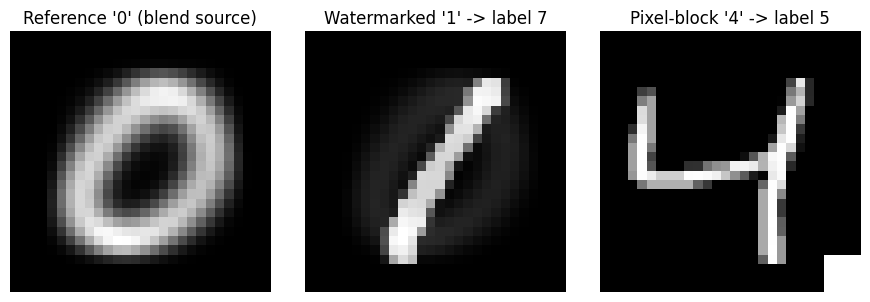

In [7]:
if __name__ == "__main__":
    train_raw = load_raw_mnist(train=True)
    reference_zero = build_reference_zero(train_raw)

    watermark_ds = PoisonedMNIST(train_raw, "watermark", mode="train",
                                  poison_rate=0.5, reference_zero=reference_zero)
    pixel_ds = PoisonedMNIST(train_raw, "pixel_block", mode="train",
                              poison_rate=0.5)

    # Grab one poisoned "1" and one poisoned "4" to visualize
    def find_poisoned_example(ds, source_label):
        for i in range(len(ds)):
            _, orig_label = ds.base[i]
            if orig_label == source_label and ds.poison_mask[i] < ds.poison_rate:
                img, new_label = ds[i]
                return img, new_label
        return None, None

    wm_img, wm_label = find_poisoned_example(watermark_ds, WATERMARK_SOURCE_LABEL)
    pb_img, pb_label = find_poisoned_example(pixel_ds, PIXEL_SOURCE_LABEL)

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(reference_zero.squeeze(), cmap="gray")
    axes[0].set_title("Reference '0' (blend source)")
    axes[1].imshow(wm_img.squeeze(), cmap="gray")
    axes[1].set_title(f"Watermarked '1' -> label {wm_label}")
    axes[2].imshow(pb_img.squeeze(), cmap="gray")
    axes[2].set_title(f"Pixel-block '4' -> label {pb_label}")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("trigger_examples.png")
    print("Saved trigger_examples.png -- check it to confirm the triggers look right.")

# Model training

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
EPOCHS = 5
POISON_RATE = 0.5  # fraction of source-label TRAIN images poisoned; see Stage 1 notes

In [10]:
class MNISTClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                       # -> 14x14x32
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                       # -> 7x7x64
            nn.Flatten(),
            nn.Linear(7 * 7 * 64, 128), nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)

In [11]:
class NormalizedWrapper(data.Dataset):
    def __init__(self, base):
        self.base = base

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        return normalize_batch(img), label


def make_loader(dataset, shuffle):
    return data.DataLoader(NormalizedWrapper(dataset), batch_size=BATCH_SIZE,
                            shuffle=shuffle, num_workers=2)

In [12]:
def train_backdoored_model(attack_type, reference_zero=None, epochs=EPOCHS):
    train_raw = load_raw_mnist(train=True)
    poisoned_train = PoisonedMNIST(train_raw, attack_type, mode="train",
                                    poison_rate=POISON_RATE,
                                    reference_zero=reference_zero)
    train_loader = make_loader(poisoned_train, shuffle=True)

    model = MNISTClassifier().to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            opt.zero_grad()
            loss = F.cross_entropy(model(imgs), labels)
            loss.backward()
            opt.step()
            total_loss += loss.item()
        print(f"[{attack_type}] epoch {epoch}: avg loss {total_loss / len(train_loader):.4f}")

    model.eval()
    return model

In [13]:
@torch.no_grad()
def evaluate_clean_accuracy(model):
    test_raw = load_raw_mnist(train=False)
    loader = make_loader(test_raw, shuffle=False)
    correct, total = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total


@torch.no_grad()
def evaluate_asr(model, attack_type, target_label, reference_zero=None):
    test_raw = load_raw_mnist(train=False)
    asr_dataset = PoisonedMNIST(test_raw, attack_type, mode="eval_asr",
                                 reference_zero=reference_zero)
    # eval_asr keeps original labels, so filter down to only the poisoned
    # (source-label) samples by re-checking against the base dataset
    source_label = WATERMARK_SOURCE_LABEL if attack_type == "watermark" else PIXEL_SOURCE_LABEL
    indices = [i for i in range(len(test_raw)) if test_raw[i][1] == source_label]
    subset = data.Subset(asr_dataset, indices)
    loader = make_loader(subset, shuffle=False)

    target_hits, total = 0, 0
    for imgs, _true_labels in loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(dim=1)
        target_hits += (preds == target_label).sum().item()
        total += preds.size(0)
    return target_hits / total


if __name__ == "__main__":
    train_raw_for_ref = load_raw_mnist(train=True)
    reference_zero = build_reference_zero(train_raw_for_ref)

    print("=== Watermark attack (1 -> 7) ===")
    global_model_watermark = train_backdoored_model("watermark", reference_zero=reference_zero)
    clean_acc_wm = evaluate_clean_accuracy(global_model_watermark)
    asr_wm = evaluate_asr(global_model_watermark, "watermark",
                           WATERMARK_TARGET_LABEL, reference_zero=reference_zero)
    print(f"Clean accuracy: {clean_acc_wm:.4f} | ASR: {asr_wm:.4f}")

    print("\n=== Pixel-block attack (4 -> 5) ===")
    global_model_pixelblock = train_backdoored_model("pixel_block")
    clean_acc_pb = evaluate_clean_accuracy(global_model_pixelblock)
    asr_pb = evaluate_asr(global_model_pixelblock, "pixel_block", PIXEL_TARGET_LABEL)
    print(f"Clean accuracy: {clean_acc_pb:.4f} | ASR: {asr_pb:.4f}")

    torch.save(global_model_watermark.state_dict(), "global_model_watermark.pt")
    torch.save(global_model_pixelblock.state_dict(), "global_model_pixelblock.pt")
    print("\nSaved both backdoored global models. These are the frozen "
          "'student' starting points for Stage 3 (ADFL defense).")

=== Watermark attack (1 -> 7) ===
[watermark] epoch 0: avg loss 0.2469
[watermark] epoch 1: avg loss 0.0578
[watermark] epoch 2: avg loss 0.0384
[watermark] epoch 3: avg loss 0.0294
[watermark] epoch 4: avg loss 0.0234
Clean accuracy: 0.9874 | ASR: 0.9974

=== Pixel-block attack (4 -> 5) ===
[pixel_block] epoch 0: avg loss 0.2138
[pixel_block] epoch 1: avg loss 0.0524
[pixel_block] epoch 2: avg loss 0.0358
[pixel_block] epoch 3: avg loss 0.0270
[pixel_block] epoch 4: avg loss 0.0218
Clean accuracy: 0.9913 | ASR: 1.0000

Saved both backdoored global models. These are the frozen 'student' starting points for Stage 3 (ADFL defense).
